# Model Training — Final (single model, bugs fixed)

This notebook replaces all previous training experiments with **one final model**.

**Decision:** `best_rf` — RandomForest tuned via `GridSearchCV` (scoring=`f1`, searches `class_weight` too), threshold = 0.32.

**Dropped (with reason):**
- RandomizedSearch RF — superseded by the wider GridSearchCV below.
- In-Process fairness (`ExponentiatedGradient`) — rejected in the original notebook's own note: extra compute/maintenance cost, no `predict_proba`, unreliable SHAP/feature_importance support.
- Manual class-weight-only RF — superseded, since GridSearchCV below already searches `class_weight` as a hyperparameter.
- Recall-optimized GridSearchCV RF — trained but never carried forward to any output in the original notebook; dropped as a dead branch.

**Bugs fixed in this version:**
1. ROC-AUC / Brier score now computed on `predict_proba()` output, not hard 0/1 predictions.
2. Business cost calculation now uses actual FN/FP counts from the confusion matrix, not a hardcoded literal.
3. SHAP and feature importance now reference the correct final model (`best_rf`), not a leftover variable from a dropped branch.
4. Hardcoded local Windows paths replaced with relative paths.
5. Model saved together with a `metadata.json` (metrics, threshold, model type) instead of an untracked lone `.pkl`.


In [3]:
import sys
sys.path.append("../")

In [5]:
from notebooks import *

## 1. Load prepared data and preprocessor

In [63]:
# Relative paths (industry-standard structure)
with open("../artifacts/models/preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

data = np.load("../artifacts/splits/x_y_splits.npz")
X_train_prep = data['X_train_prep']
X_test_prep = data['X_test_prep']
y_train = data['y_train']
y_test = data['y_test']

scaled_data_X_train = pd.read_csv("../data/processed/scaled_data_X_train.csv")
scaled_data_copy_test_df = pd.read_csv("../data/processed/scaled_data__copy_test_df.csv")


## 2. Baseline model comparison (kept for reference — not used for final selection)

Accuracy is shown here only as a quick sanity check across algorithms. It is **not** the metric used to pick the final model, since the target is imbalanced (~22% default rate).

In [64]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

def baseline_comparison(X_train, X_test, y_train, y_test, models):
    names, scores = [], []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)
        names.append(name)
        scores.append(score)
    report = pd.DataFrame({"Model_Name": names, "Accuracy": scores})
    return report.sort_values(by="Accuracy", ascending=False)

baseline_comparison(X_train_prep, X_test_prep, y_train, y_test, models)


,Model_Name,Accuracy
7,CatBoost,0.935604
6,XGBoost,0.934447
1,Random Forest,0.932391
3,Gradient Boosting,0.928792
2,AdaBoost,0.889203
5,Decision Tree,0.888175
4,KNN,0.875450
0,Logistic Regression,0.853213


## 3. Class weight reference (informative — GridSearchCV below searches this too)

In [65]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Reference balanced class weights: {class_weight_dict}")


Reference balanced class weights: {0: np.float64(0.6399661542800733), 1: np.float64(2.2861460957178843)}


## 4. Final model — GridSearchCV-tuned Random Forest (`best_rf`)

Grid search optimizes F1 (better than accuracy for imbalanced data) and searches `class_weight` as a hyperparameter, so this supersedes the earlier manual class-weight and RandomizedSearch attempts.

In [29]:
def rf_grid_search(X_train, y_train):
    param_grid = {
        'n_estimators': [150, 300, 450],
        'max_depth': [10, 20, 30],
        'min_samples_split': [2, 5, 8],
        'min_samples_leaf': [1, 2, 3, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': [{0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}],
    }
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(
        estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='f1', verbose=1
    )
    grid_search.fit(X_train, y_train)
    print("Best Params:", grid_search.best_params_)
    print("Best CV F1 Score:", grid_search.best_score_)
    return grid_search

rf_grid_search_result = rf_grid_search(X_train_prep, y_train)


Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best Params: {'class_weight': {0: 1, 1: 2}, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 450}
Best CV F1 Score: 0.8170450143114872


In [66]:
best_rf = RandomForestClassifier(
    **{'class_weight': {0: 1, 1: 2}, 'max_depth': 20, 'max_features': 'sqrt', 
       'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 450},
    random_state=42
)
best_rf.fit(X_train_prep, y_train)

y_pred = best_rf.predict(X_test_prep)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9317480719794344
              precision    recall  f1-score   support

       False       0.93      0.99      0.96      6079
        True       0.96      0.72      0.82      1701

    accuracy                           0.93      7780
   macro avg       0.94      0.86      0.89      7780
weighted avg       0.93      0.93      0.93      7780



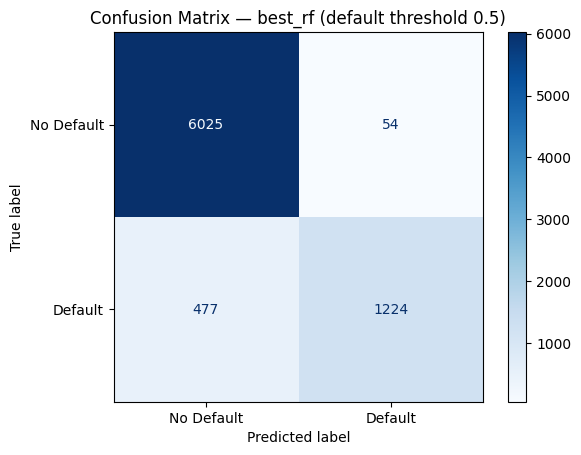

In [67]:
ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test_prep, y_test, display_labels=['No Default', 'Default'], cmap='Blues'
)
plt.title('Confusion Matrix — best_rf (default threshold 0.5)')
plt.show()


## 5. Threshold adjustment (uses `predict_proba` — this part was already correct)

In [68]:
rf_probs = best_rf.predict_proba(X_test_prep)[:, 1]  # probability of default

thresholds = [0.2, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.32, 0.33, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

print("Threshold | Recall | Precision | F1-Score")
print("-" * 50)
for t in thresholds:
    y_pred_t = (rf_probs >= t).astype(int)
    print(f"{t:>9} | {recall_score(y_test, y_pred_t):.2f}   | {precision_score(y_test, y_pred_t):.2f}      | {f1_score(y_test, y_pred_t):.2f}")


Threshold | Recall | Precision | F1-Score
--------------------------------------------------
      0.2 | 0.85   | 0.61      | 0.71
     0.25 | 0.81   | 0.72      | 0.76
     0.26 | 0.80   | 0.73      | 0.77
     0.27 | 0.80   | 0.75      | 0.77
     0.28 | 0.79   | 0.78      | 0.78
     0.29 | 0.79   | 0.79      | 0.79
      0.3 | 0.78   | 0.81      | 0.80
     0.32 | 0.77   | 0.83      | 0.80
     0.33 | 0.77   | 0.85      | 0.81
     0.35 | 0.76   | 0.87      | 0.81
      0.4 | 0.75   | 0.91      | 0.82
     0.45 | 0.73   | 0.94      | 0.82
      0.5 | 0.72   | 0.96      | 0.82
     0.55 | 0.71   | 0.96      | 0.82
      0.6 | 0.70   | 0.98      | 0.82


**Chosen threshold: 0.32** — best recall/precision/F1 balance from the sweep above.

In [69]:
FINAL_THRESHOLD = 0.32
rf_preds = (rf_probs >= FINAL_THRESHOLD).astype(int)

print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))


Accuracy: 0.9167095115681234
              precision    recall  f1-score   support

       False       0.94      0.96      0.95      6079
        True       0.83      0.77      0.80      1701

    accuracy                           0.92      7780
   macro avg       0.89      0.87      0.87      7780
weighted avg       0.92      0.92      0.92      7780



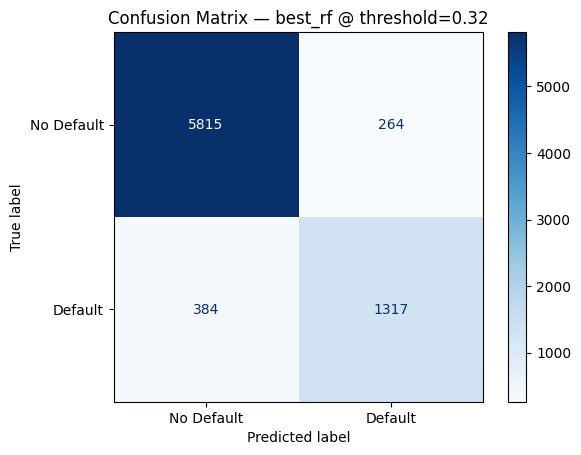

In [70]:
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, display_labels=['No Default', 'Default'], cmap='Blues'
)
plt.title(f'Confusion Matrix — best_rf @ threshold={FINAL_THRESHOLD}')
plt.show()


#### Check for Data Leakage

In [ ]:
from sklearn.model_selection import cross_val_score

def check_leakage(model, X_train, y_train, X_test, y_test, threshold=0.05):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, model.predict(X_test))
    gap = train_acc - test_acc

    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Gap:            {gap:.4f}")

    if gap > threshold:
        print("WARNING: Large train-test gap — possible DATA LEAKAGE or overfitting!")
    else:
        print("Gap is small — model looks safe, no obvious leakage.")

    # cross check with cross validation    
    cv_scores = cross_val_score(best_rf, X_train_prep, y_train, cv=5, scoring='accuracy')
    print(f"CV Mean: {cv_scores.mean():.4f} | CV Std: {cv_scores.std():.4f}")

    if train_acc > 0.99:
        print("Train accuracy near 100% — check for leaked features")


In [72]:
check_leakage(best_rf, X_train_prep, y_train, X_test_prep, y_test)

Train Accuracy: 0.9784
Test Accuracy:  0.9317
Gap:            0.0467
✅ Gap is small — model looks safe, no obvious leakage.
CV Mean: 0.9301 | CV Std: 0.0053


## 6. Business cost (FIXED — now uses actual confusion-matrix counts, not a hardcoded literal)

In [73]:
fn_cost = 378  # cost of missing an actual defaulter (approved, then defaults)
fp_cost = 316  # cost of wrongly rejecting a good applicant

tn, fp, fn, tp = confusion_matrix(y_test, rf_preds).ravel()
total_cost = (fn * fn_cost) + (fp * fp_cost)
print(f"FN={fn}, FP={fp}")
print(f"Total Business Loss: Rs. {total_cost}")


FN=384, FP=264
Total Business Loss: Rs. 228576


## 7. ROC-AUC / Brier score / Precision-Recall curve (FIXED — uses `rf_probs`, not hard `rf_preds`)

In [74]:
roc_auc = roc_auc_score(y_test, rf_probs)
brier_score = brier_score_loss(y_test, rf_probs)

print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Brier Score Loss: {brier_score:.4f} (lower is better)")


ROC AUC Score: 0.9347
Brier Score Loss: 0.0599 (lower is better)


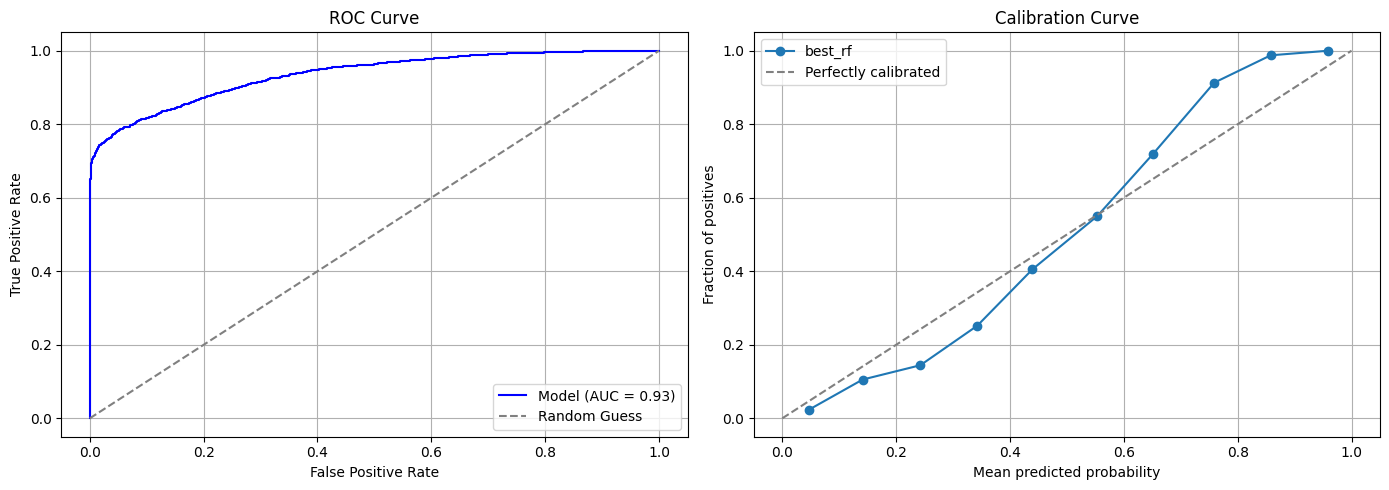

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, rf_probs)
ax[0].plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
ax[0].set_xlabel('False Positive Rate'); ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve'); ax[0].legend(); ax[0].grid(True)

prob_true, prob_pred = calibration_curve(y_test, rf_probs, n_bins=10)
ax[1].plot(prob_pred, prob_true, marker='o', label='best_rf')
ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax[1].set_xlabel('Mean predicted probability'); ax[1].set_ylabel('Fraction of positives')
ax[1].set_title('Calibration Curve'); ax[1].legend(); ax[1].grid(True)

plt.tight_layout()
plt.show()


#### PR-AUC Score

In [76]:
precision, recall, _ = precision_recall_curve(y_test, rf_probs)
pr_auc = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc:.4f}")

PR-AUC Score: 0.8868


#### Ideal vs Typical PR curve

In [77]:
# your model's actual curve 
precision, recall, thresholds = precision_recall_curve(y_test, rf_probs)
thresholds_padded = np.append(thresholds, thresholds[-1])  # length match karne ke liye

# Fake/synthetic "ideal" curve
recall_ideal = np.linspace(0, 1, 100)
precision_ideal = np.where(recall_ideal < 0.7,
                            1 - 0.05 * recall_ideal,
                            1 - 0.05 * 0.7 - 1.5 * (recall_ideal - 0.7))
precision_ideal = np.clip(precision_ideal, 0, 1)

# Plots
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recall, y=precision, mode='lines+markers',
    name='Your model',
    line=dict(color='#2a78d6', width=2),
    marker=dict(size=4),
    customdata=thresholds_padded,
    hovertemplate='Recall: %{x:.2f}<br>Precision: %{y:.2f}<br>Threshold: %{customdata:.2f}<extra>Your model</extra>'
))

# Ideal curve
fig.add_trace(go.Scatter(
    x=recall_ideal, y=precision_ideal, mode='lines',
    name='Ideal (synthetic)',
    line=dict(color='green', width=2.5),
    hovertemplate='Recall: %{x:.2f}<br>Precision: %{y:.2f}<extra>Ideal</extra>'
))

fig.update_layout(
    title='Precision-Recall Curve: Your model vs Ideal',
    xaxis_title='Recall',
    yaxis_title='Precision',
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
    template='plotly_white',
    legend=dict(x=0.02, y=0.05)
)

fig.show()

## 8. Top-K high-risk customers

In [78]:
df_precision_k = pd.DataFrame({
    'actual': y_test,
    'pred_class': rf_preds,
    'pred_prob': rf_probs,
}).sort_values(by='pred_prob', ascending=False).reset_index(drop=True)

print("Top 20 highest-risk customers:")
df_precision_k.head(20)


Top 20 highest-risk customers:


,actual,pred_class,pred_prob
0,True,1,1.000000
1,True,1,0.999481
2,True,1,0.999259
3,True,1,0.998272
4,True,1,0.997905
5,True,1,0.997778
6,True,1,0.997576
7,True,1,0.997500
8,True,1,0.997401
9,True,1,0.997160


## 9. Save final model + metadata (FIXED — versioned artifacts, relative paths, no lone untracked pkl)

In [79]:
os.makedirs("../artifacts/models", exist_ok=True)

with open("../artifacts/models/final_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

metadata = {
    "model_type": "RandomForestClassifier",
    "selection_method": "GridSearchCV",
    "scoring": "f1",
    "best_params": {'class_weight': {0: 1, 1: 2}, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 450},
    "final_threshold": FINAL_THRESHOLD,
    "metrics": {
        "roc_auc": round(float(roc_auc), 4),
        "brier_score": round(float(brier_score), 4),
        "pr_auc": round(float(pr_auc), 4),
        "business_cost": int(total_cost),
    },
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
}

with open("../artifacts/models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved final_model.pkl and metadata.json")
print(json.dumps(metadata, indent=2))


Saved final_model.pkl and metadata.json
{
  "model_type": "RandomForestClassifier",
  "selection_method": "GridSearchCV",
  "scoring": "f1",
  "best_params": {
    "class_weight": {
      "0": 1,
      "1": 2
    },
    "max_depth": 20,
    "max_features": "sqrt",
    "min_samples_leaf": 1,
    "min_samples_split": 5,
    "n_estimators": 450
  },
  "final_threshold": 0.32,
  "metrics": {
    "roc_auc": 0.9347,
    "brier_score": 0.0599,
    "pr_auc": 0.8868,
    "business_cost": 228576
  },
  "trained_at_utc": "2026-09-09T07:58:28.179300+00:00"
}


## 10. SHAP feature explanation (FIXED — now uses `best_rf`, the actual final model)

In [ ]:
def explain_rows_with_shap(model, preprocessor, rows_dict, scaled_data_X_train, threshold=FINAL_THRESHOLD):
    feature_names = scaled_data_X_train.columns
    explainer = shap.TreeExplainer(model)
    for label, raw_row in rows_dict.items():
        row_df = pd.DataFrame([raw_row])
        row_prep = preprocessor.transform(row_df)
        proba = model.predict_proba(row_prep)[:, 1][0]
        decision = "Default" if proba >= threshold else "No Default"
        print(f"{label}: probability={proba:.3f} -> {decision}")
        shap_values = explainer.shap_values(row_prep)
        
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]   # (1, 27, 2) -> (1, 27), class 1 (Default)

        shap.summary_plot(shap_values, row_prep, feature_names=feature_names, plot_type='bar', max_display=len(feature_names), show=False)

        fig = plt.gcf()
        fig.set_size_inches(10, 12)
        plt.tight_layout()
        plt.show()


{'Income': 30000, 'Home_ownership': 'Own', 'Employment_length': 10, 'Loan_intent': 'Personal', 'internal_credit_rating': 7, 'Loan_amount': 1000000, 'Interest_rate': 7.55, 'Loan_percent_income': 33.33, 'Default': False, 'Credit_history_length': 8, 'credit_score': 785.12, 'age_group': '36-45', 'is_eligible': True, 'high_risk_flag': False, 'age_employment_ratio': 0.2857, 'income_per_credit_year': 3750}
29
example_customer: probability=0.140 -> No Default


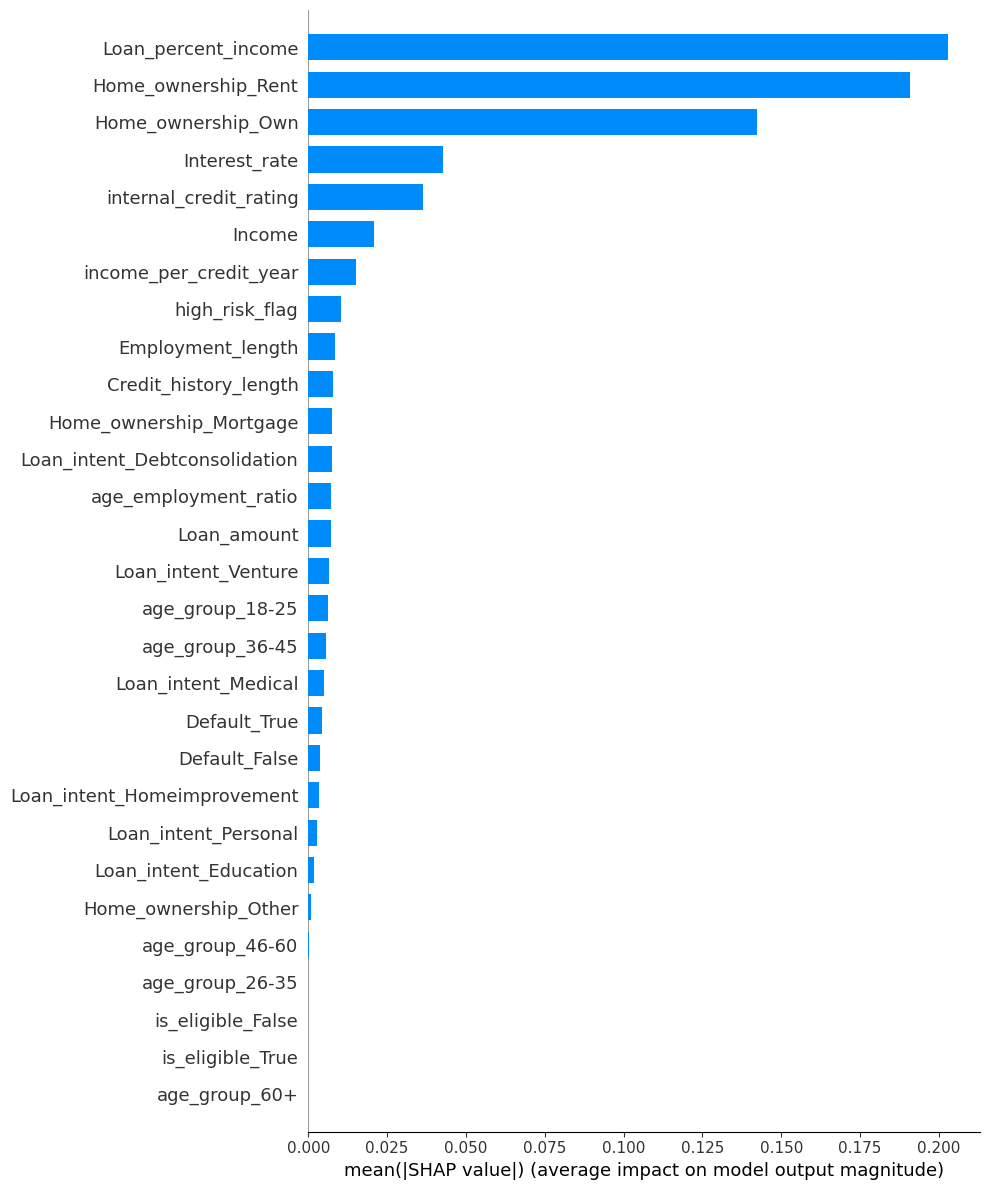

In [81]:
example_customer = {
    "Income": 30000,
    "Home_ownership": "Own",
    "Employment_length": 10,
    "Loan_intent": "Personal",
    "internal_credit_rating": 7,
    "Loan_amount": 1000000,
    "Interest_rate": 7.55,
    "Loan_percent_income": 33.33,
    "Default": False,
    "Credit_history_length": 8,
    "credit_score": 785.120,
    "age_group": "36-45",
    "is_eligible": True,
    "high_risk_flag": False,
    "age_employment_ratio": 0.2857,
    "income_per_credit_year": 3750
}

explain_rows_with_shap(best_rf, preprocessor, {"example_customer": example_customer}, scaled_data_X_train)


## 11. Feature importance (FIXED — now uses `best_rf`, not a leftover variable)

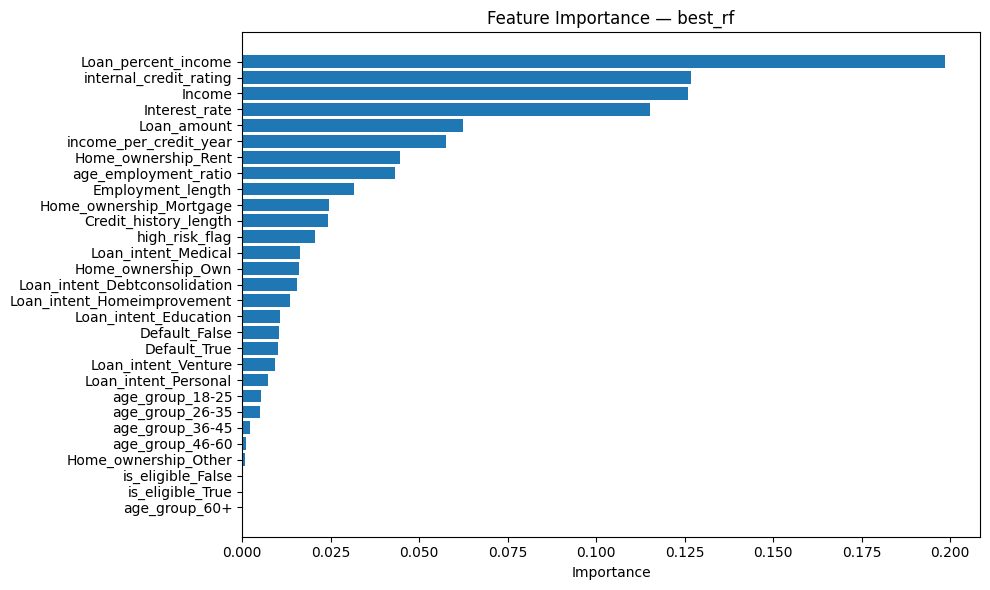

In [82]:
feat_imp = pd.DataFrame({
    "feature": scaled_data_X_train.columns,
    "importance": best_rf.feature_importances_,
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.xlabel("Importance")
plt.title("Feature Importance — best_rf")
plt.tight_layout()
plt.show()


In [83]:
np.save("../artifacts/predictions/fair_prediction.npy", rf_preds)
print("Saved predictions to ../artifacts/predictions/fair_prediction.npy")


Saved predictions to ../artifacts/predictions/fair_prediction.npy
